In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('DS_companies.csv')
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [10]:
df.drop(df[['Unnamed: 0','salary']],axis=1,inplace=True)

In [11]:
df.head()

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,USD,150000,US,50,US,L


In [18]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [13]:
df['work_year'].unique()

array([2020, 2021, 2022])

In [15]:
df1 = df.groupby('work_year')['salary_in_usd'].mean().round(2)
df1

work_year
2020     95813.00
2021     99853.79
2022    124522.01
Name: salary_in_usd, dtype: float64

In [16]:
df1.index

Index([2020, 2021, 2022], dtype='int64', name='work_year')

In [19]:
df1.values

array([ 95813.  ,  99853.79, 124522.01])

In [21]:
data = {'work_year' : df1.index, 'average_salary' : df1.values}
df1 = pd.DataFrame(data)
df1

,work_year,average_salary
0,2020,95813.00
1,2021,99853.79
2,2022,124522.01


In [23]:
df1.index

RangeIndex(start=0, stop=3, step=1)

In [22]:
df1['average_salary'] = (df1['average_salary']/1000).round(2)
df1

,work_year,average_salary
0,2020,95.81
1,2021,99.85
2,2022,124.52


<Axes: xlabel='work_year'>

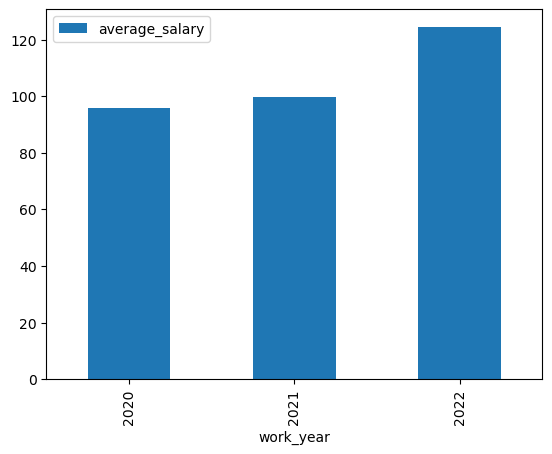

In [25]:
df1.plot(kind = 'bar', x = 'work_year', y = 'average_salary')

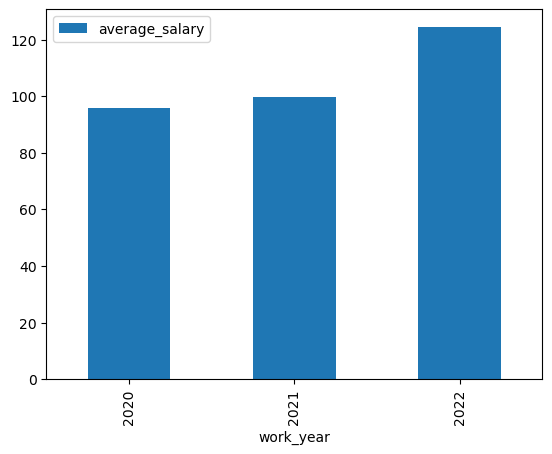

In [27]:
ax = df1.plot(kind = 'bar', x = 'work_year', y = 'average_salary', legend = True)

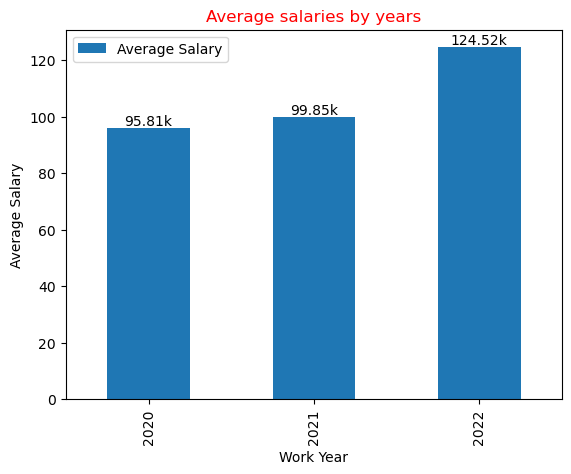

In [30]:
ax = df1.plot(kind = 'bar', x = 'work_year', y = 'average_salary', legend = True)
ax.bar_label(ax.containers[0],labels= df1['average_salary'].map('{:.2f}k'.format))
ax.legend(['Average Salary'], loc = 'upper left')
plt.xlabel('Work Year')
plt.ylabel('Average Salary')
plt.title('Average salaries by years', color = 'red')
plt.show()

In [31]:
print(ax.containers)
print(ax.containers[0])

[<BarContainer object of 3 artists>]
<BarContainer object of 3 artists>


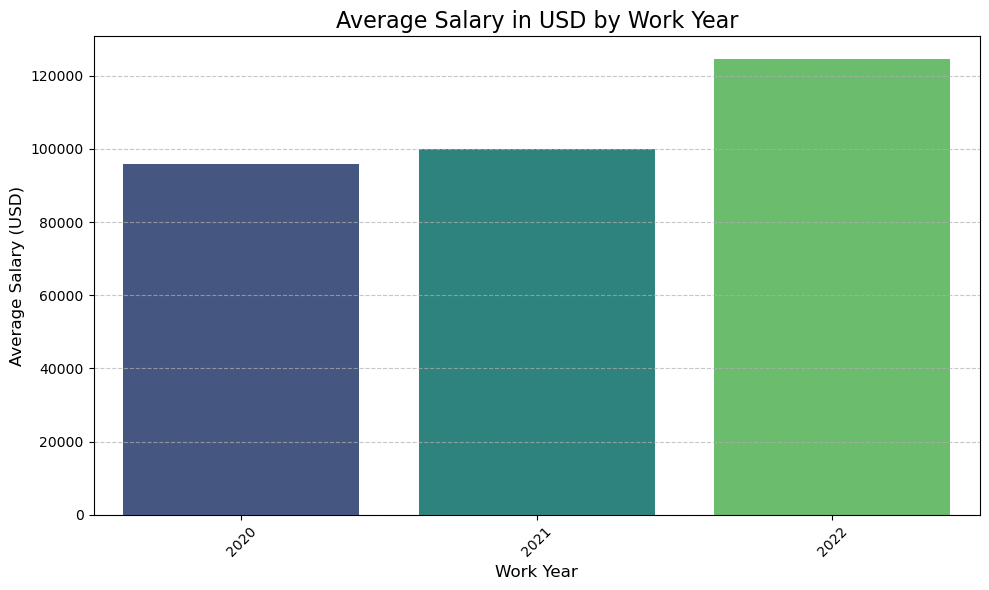

In [5]:
salary_by_year = df.groupby('work_year')['salary_in_usd'].mean().reset_index()

# Bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=salary_by_year, x='work_year', y='salary_in_usd', palette='viridis')
plt.title('Average Salary in USD by Work Year', fontsize=16)
plt.xlabel('Work Year', fontsize=12)
plt.ylabel('Average Salary (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Remote Work Trends

In [32]:
df.remote_ratio.unique()

array([  0,  50, 100])

In [34]:
df2 = df.remote_ratio.value_counts()
df2

remote_ratio
100    381
0      127
50      99
Name: count, dtype: int64

In [36]:
values = df2.to_list()
values

[381, 127, 99]

In [37]:
labels = ['Fully remote', 'No remote', 'Partially remote']
labels

['Fully remote', 'No remote', 'Partially remote']

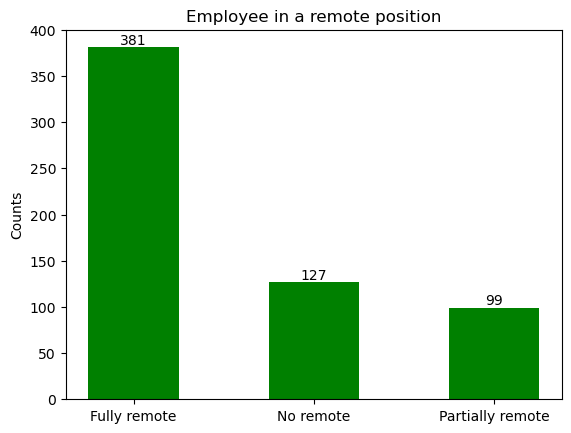

In [40]:
z = plt.bar(labels,values,width=0.5, color = 'green')
plt.bar_label(z, labels = values)
plt.title('Employee in a remote position')
plt.ylabel('Counts')
plt.show()

In [41]:
df.company_size.unique()

array(['L', 'S', 'M'], dtype=object)

In [43]:
df3 = df.company_size.value_counts()
df3

company_size
M    326
L    198
S     83
Name: count, dtype: int64

In [44]:
df3.index.to_list()

['M', 'L', 'S']

In [45]:
df3.index

Index(['M', 'L', 'S'], dtype='object', name='company_size')

In [46]:
value2 = df3.to_list()
value2

[326, 198, 83]

In [47]:
labels_for_company = ['Medium','Large','Small']
labels_for_company

['Medium', 'Large', 'Small']

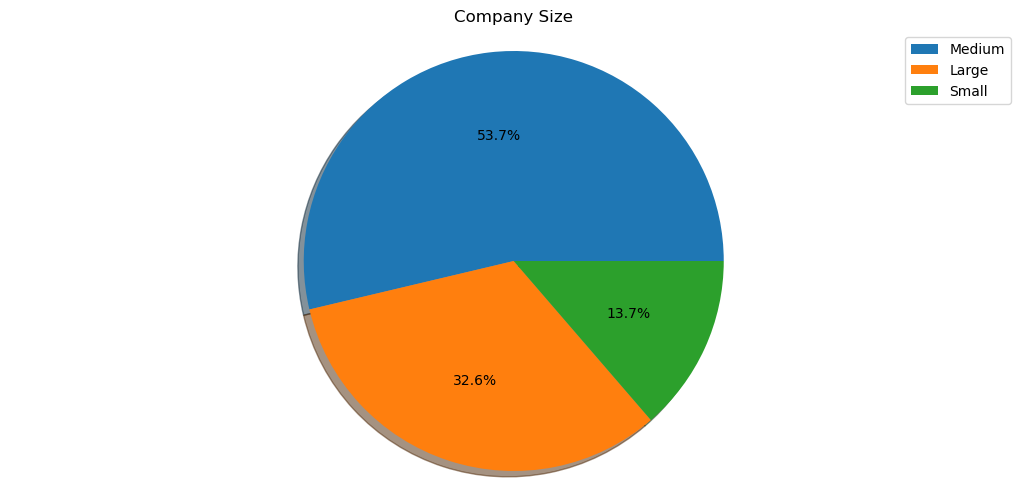

In [51]:
plt.figure(figsize=(13,6))
plt.pie(x = value2, labels=None, autopct='%1.1f%%',shadow=True)
plt.legend(labels = labels_for_company, loc = 'upper right')
plt.axis('equal')
plt.title('Company Size')
plt.show()

In [52]:
df.head(3)

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,GBP,109024,GB,50,GB,M


## Job Title Analysis

In [53]:
df.job_title.value_counts()

job_title
Data Scientist                              143
Data Engineer                               132
Data Analyst                                 97
Machine Learning Engineer                    41
Research Scientist                           16
Data Science Manager                         12
Data Architect                               11
Big Data Engineer                             8
Machine Learning Scientist                    8
Principal Data Scientist                      7
AI Scientist                                  7
Data Science Consultant                       7
Director of Data Science                      7
Data Analytics Manager                        7
ML Engineer                                   6
Computer Vision Engineer                      6
BI Data Analyst                               6
Lead Data Engineer                            6
Data Engineering Manager                      5
Business Data Analyst                         5
Head of Data                  

In [61]:
df4 = df.job_title.value_counts().head(5)
df4

job_title
Data Scientist               143
Data Engineer                132
Data Analyst                  97
Machine Learning Engineer     41
Research Scientist            16
Name: count, dtype: int64

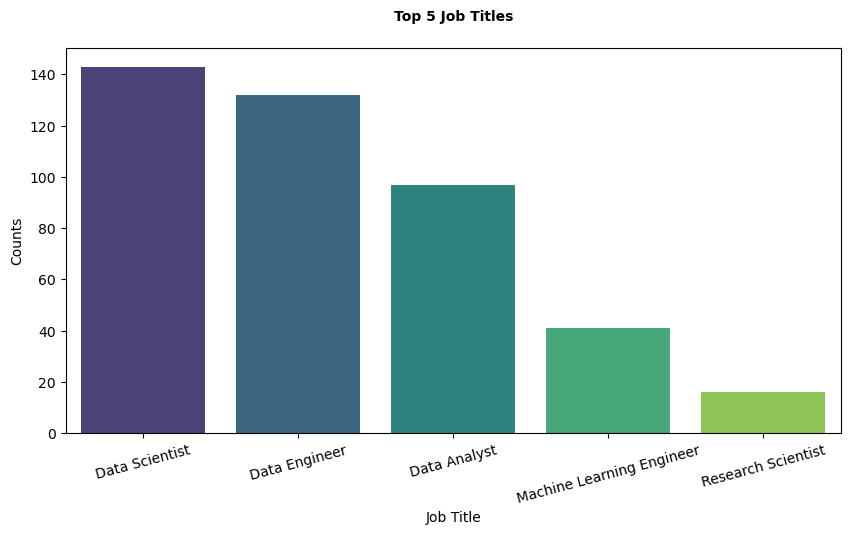

In [62]:
plt.figure(figsize=(10,5))
sns.barplot(x= df4.index, y = df4.values,palette='viridis')
plt.title('Top 5 Job Titles', fontweight = 'bold', fontsize = 10,pad = 20)
plt.ylabel('Counts')
plt.xlabel('Job Title')
plt.xticks(rotation = 15)
plt.show()

In [63]:
## Salary Distribution 

In [65]:
df5 = df[['salary_in_usd','company_size']]
df5

,salary_in_usd,company_size
0,79833,L
1,260000,S
2,109024,M
3,20000,S
4,150000,L
...,...,...
602,154000,M
603,126000,M
604,129000,M
605,150000,M


In [66]:
S = df5[df5['company_size'] == 'S']
M = df5[df5['company_size'] == 'M']
L = df5[df5['company_size'] == 'L']
labels = ['Small','Medium','Large']
sal_mean = [S['salary_in_usd'].mean(),M['salary_in_usd'].mean(),L['salary_in_usd'].mean()]
sal_mean

[np.float64(77632.67469879518),
 np.float64(116905.46625766871),
 np.float64(119242.99494949495)]

In [67]:
label_change = np.round([x for x in sal_mean], 1)
label_change = list(map(str,label_change))
label_change = [x+'$' for x in label_change]
label_change

['77632.7$', '116905.5$', '119243.0$']

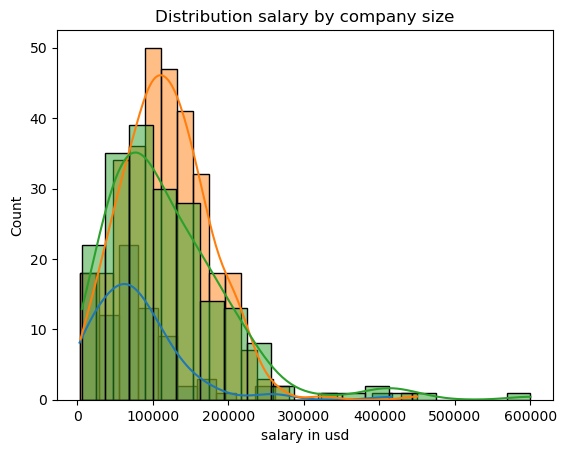

In [68]:
sns.histplot(S['salary_in_usd'], label = 'Small', kde = True)
sns.histplot(M['salary_in_usd'], label = 'Medium', kde = True)
sns.histplot(L['salary_in_usd'], label = 'Large', kde = True)
plt.title('Distribution salary by company size')
plt.xlabel('salary in usd')
plt.show()

In [74]:
df6 = df.experience_level.value_counts()
df6

experience_level
SE    280
MI    213
EN     88
EX     26
Name: count, dtype: int64

In [73]:
df6.index.to_list()

['SE', 'MI', 'EN', 'EX']

In [75]:
value6 = df6.to_list()
value6

[280, 213, 88, 26]

In [76]:
labels_for_experience = ['Senior', 'Middle', 'Entry Level', 'Executive']
labels_for_experience

['Senior', 'Middle', 'Entry Level', 'Executive']

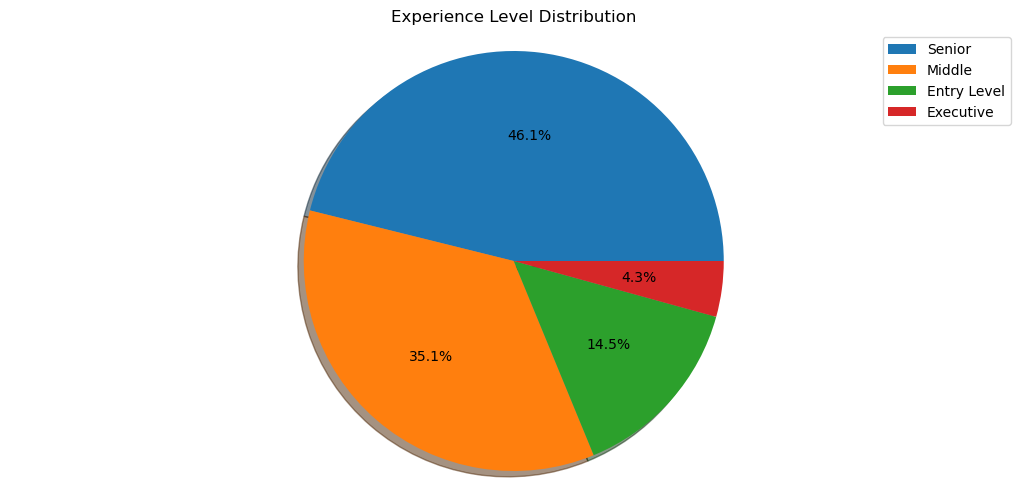

In [77]:
plt.figure(figsize=(13, 6))
plt.pie(x=value6, labels=None, autopct='%1.1f%%', shadow=True)
plt.legend(labels=labels_for_experience, loc='upper right')
plt.axis('equal')
plt.title('Experience Level Distribution')
plt.show()

## Senior level employees have the highest proportion, followed by Middle and Entry Level. Executive level has the smallest share, showing a typical organizational pyramid structure.

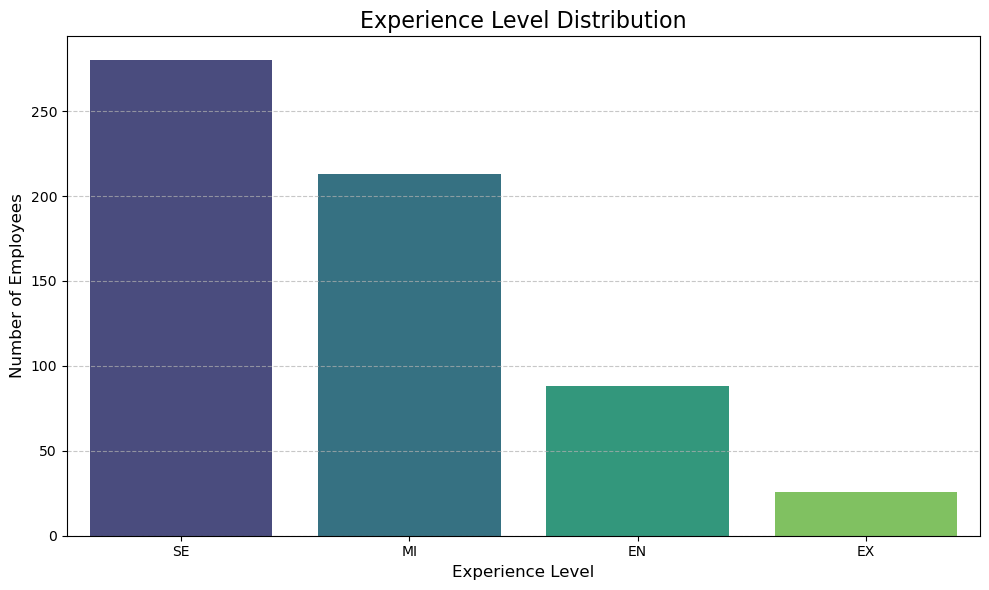

In [78]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df6.index, y=df6.values, palette='viridis')
plt.title('Experience Level Distribution', fontsize=16)
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
